In [394]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import linregress

In [16]:
def read_df(path):
    df = pd.read_csv(path, header=None)
    cols = [x.split(":")[0] for x in df.iloc[0]]
    df.columns = cols
    for col in cols:
        df[col] = df[col].str.split(":").str[1].astype(int)
    return df

In [454]:
def clamp_diff(series, diff):
    result = series.copy()
    for i in range(1, len(result)):
        if result.iloc[i] > result.iloc[i-1] + diff:
            result.iloc[i] = result.iloc[i-1] + diff
        elif result.iloc[i] < result.iloc[i-1] - diff:
            result.iloc[i] = result.iloc[i-1] - diff
    return result

In [505]:
baseline = read_df("dark-baselines.csv")
del baseline["Distance"]
baseline

,TEMT6000,LDR
0,20,19
1,20,20
2,19,20
3,20,20
4,20,20
...,...,...
240,20,20
241,20,19
242,19,20
243,20,20


Text(0.5, 1.0, 'Avstand over tid')

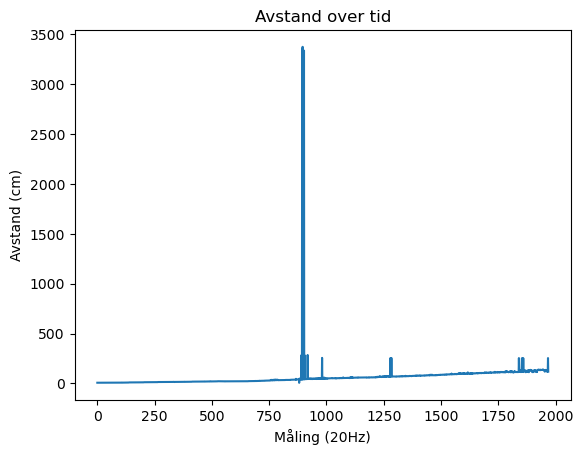

In [549]:
#| label: distance-raw
df = read_df("dark-flashlight3-long-slow.csv")
df["Distance"].plot()
plt.xlabel("Måling (20Hz)")
plt.ylabel("Avstand (cm)")
plt.title("Avstand over tid")

,TEMT6000,LDR,Distance
0,1000,859,7
1,1000,859,7
2,999,860,7
3,996,860,7
4,999,860,7
...,...,...,...
1964,2,32,132
1965,1,31,131
1966,1,32,132
1967,1,32,133


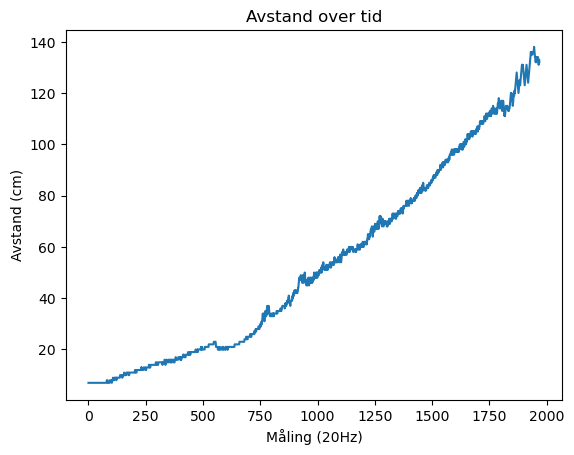

In [580]:
#| label: distance-clamped
df = read_df("dark-flashlight3-long-slow.csv") # Closest to linear
#df = read_df("dark-flashlight5.csv") # 3.
#df = read_df("dark-flashlight2-long.csv") # 2.
#df = read_df("dark-flashlight1.csv") # 4.

#df = df[df["Distance"] < 150]
df["Distance"] = clamp_diff(df["Distance"], 1)
#df.iloc[1075:1150].reset_index().plot(x="index", y="Distance", kind="scatter")
#df.reset_index().plot(x="index", y="Distance", kind="scatter")
df["Distance"].plot()
plt.xlabel("Måling (20Hz)")
plt.ylabel("Avstand (cm)")
plt.title("Avstand over tid")
#df = df[df["Distance"] == df["Distance"].cummax()]
df

LDR = 20.0 ± 1.0
Intervallstørrelse: 830
Variasjonsbredde = 2 ~ 0.12% av intervall


Text(0.5, 1.0, 'Lysintensitet i mørkt rom (fotoresistor)')

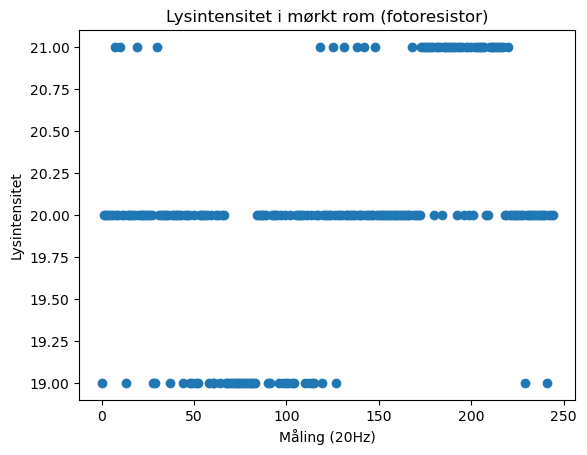

In [581]:
#| label: baseline-ldr

ldr = baseline["LDR"]
ldr_range = df["LDR"].max() - df["LDR"].min()
variasjon = ldr.max() - ldr.min()
avvik = variasjon / 2
avvik_forhold = avvik / ldr_range * 100
ldr_baseline = ldr.mean()
print(f"LDR = {ldr_baseline:.1f} ± {avvik:.1f}")
print(f"Intervallstørrelse: {ldr_range}")
print(f"Variasjonsbredde = {variasjon} ~ {avvik_forhold:.2f}% av intervall")

plt.scatter(baseline.index, baseline["LDR"])
plt.xlabel("Måling (20Hz)")
plt.ylabel("Lysintensitet")
plt.title("Lysintensitet i mørkt rom (fotoresistor)")

TEMT = 19.9 ± 1.0
Intervallstørrelse: 1000
Variasjonsbredde = 2 ~ 0.10% av intervall


Text(0.5, 1.0, 'Lysintensitet i mørkt rom (TEMT6000)')

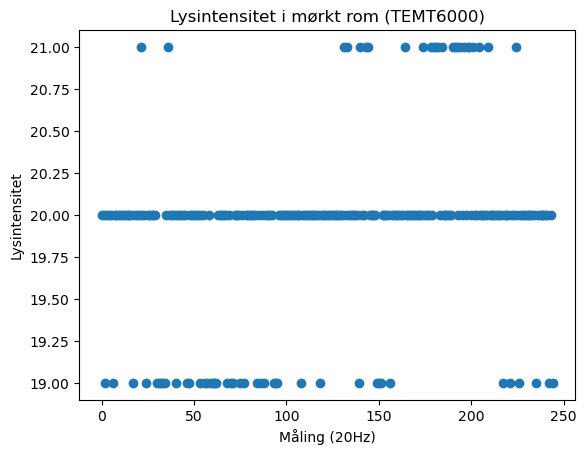

In [582]:
#| label: baseline-temt
temt = baseline["TEMT6000"]
temt_range = df["TEMT6000"].max() - df["TEMT6000"].min()
variasjon = temt.max() - temt.min()
avvik = variasjon / 2
avvik_forhold = avvik / temt_range * 100
temt_baseline = temt.mean()
print(f"TEMT = {temt_baseline:.1f} ± {avvik:.1f}")
print(f"Intervallstørrelse: {temt_range}")
print(f"Variasjonsbredde = {variasjon} ~ {avvik_forhold:.2f}% av intervall")

plt.scatter(baseline.index, baseline["TEMT6000"])
plt.xlabel("Måling (20Hz)")
plt.ylabel("Lysintensitet")
plt.title("Lysintensitet i mørkt rom (TEMT6000)")

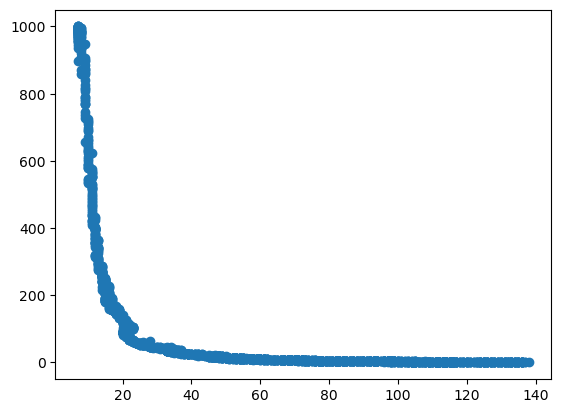

In [591]:
plt.scatter(df["Distance"], df["TEMT6000"])

Text(0.5, 1.0, 'Linearized plot of intensity vs distance')

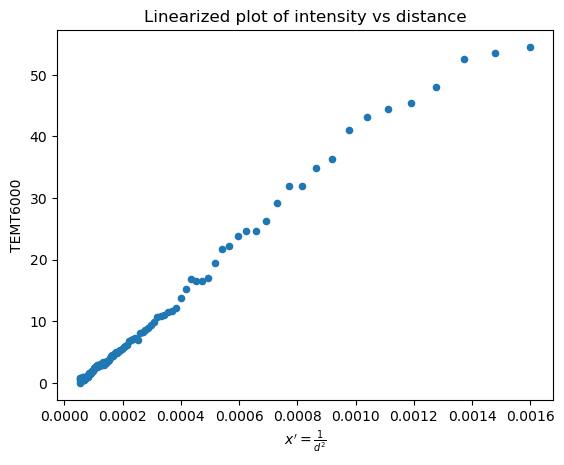

In [618]:
#| label: df-grouped
df2 = df.groupby("Distance").mean()
df2["TEMT6000"] -= df2["TEMT6000"].min()
df2["LDR"] -= df2["LDR"].min()
df2 = df2[(df2.index >= 25)]
df2["x2"] = 1 / (df2.index ** 2)

df2.plot(x=r"x2", y="TEMT6000", kind="scatter")
plt.xlabel(r"$x'=\frac{1}{d^2}$")
plt.title("Linearized plot of intensity vs distance")

In [627]:
a, b, r, _, _ = linregress(df2["x2"], df2["TEMT6000"])
print(f"f(x) = ax + b ≈ {a:.0f}x - {-b:.3f}")
print(f"R^2 = {r**2:.3f}")

f(x) = ax + b ≈ 39945x - 1.925
R^2 = 0.992


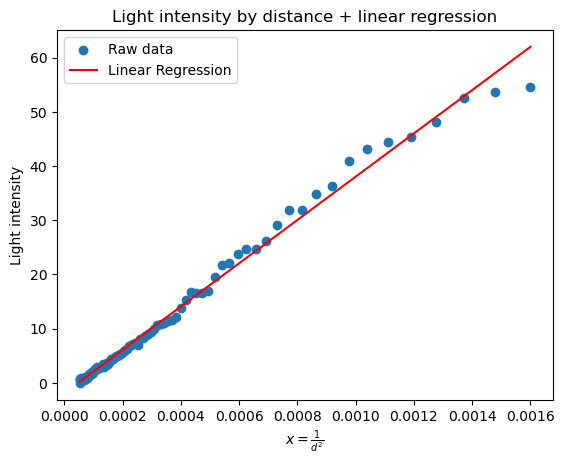

In [632]:
#| label: temt-linear-regression

fig, ax = plt.subplots()

xs = df2["x2"]
ys = a * df2["x2"] + b

ax.scatter(xs, df2["TEMT6000"], label="Raw data")
ax.plot(df2["x2"], ys, color="red", label="Linear Regression")

ax.set_xlabel(r"$x=\frac{1}{d^2}$")
ax.set_ylabel("Light intensity")
ax.set_title("Light intensity by distance + linear regression")
ax.legend()

In [636]:
log_d = np.log(df2.index.values)
log_temt = np.log(df2["TEMT6000"].values - b)

a_log, _ = np.polyfit(log_d, log_temt, 1)

print(f"Exponent ≈ {slope_log:.3f}")

Exponent ≈ -1.994
